<h1>Pontificia Universidade Católica de Minas Gerais</h1>
<h2>PÓS-GRADUAÇÃO EM Inteligencia artificial e aprendizado de máquina</h2>


* Nome do aluno: Wagner Jose Vaconcelos
* Matrícula: 1665641
* E-mail: 1665641@sga.pucminas.br
* Professor(a): Maurício Rodrigues da Silva
* Disciplina: "Machine Learning"
* Atividade: Tarefa 4 - Modelagem Preditiva com Algoritmos Supervisionados

## Objetivos

Desenvolver um projeto de classificação utilizando uma das bases de dados disponíveis no portal do aluno. O aluno deverá aplicar de um a dois algoritmos supervisionados entre os seguintes:

Regressão Logística

Naive Bayes

Redes Neurais

O foco é construir modelos preditivos, avaliar seu desempenho e interpretar os resultados com base nas variáveis disponíveis.

## 1. Definição do problema

**Objetivo**: O problema a ser resolvido será definir atraves de dados simulados de informações sobre um cliente e o credito requisitado, se é classificado como alto ou baixo risco.

**Tipo de problema**: Classificação binária 0 - Baixo risco 1 - Alto risco.

**Dataset**: dados_risco_credito.csv Dados simulados sobre risco de crédito de clientes.


#### 2. Coleta e Preparação dos Dados

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import shap
import lime
import lime.lime_tabular
import joblib
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
import joblib

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)


file_path = 'dataset/dados_risco_credito.csv'

# Carregando o dataset a partir do arquivo local.
risco_credito = pd.read_csv(file_path, sep=',')

In [4]:
risco_credito.head()

,idade,renda_mensal,historico_credito,tempo_emprego,tipo_residencia,estado_civil,numero_dependentes,valor_solicitado,finalidade_credito,risco
0,56,1090.33,Ruim,14,Própria,Solteiro,1,26978.03,Negócio,Alto Risco
1,69,3805.20,Bom,3,Própria,Casado,0,24718.47,Imóvel,Alto Risco
2,46,2365.47,Bom,11,Própria,Casado,3,16528.29,Imóvel,Baixo Risco
3,32,1366.62,Regular,5,Alugada,Divorciado,0,9989.08,Educação,Alto Risco
4,60,2530.14,Ruim,18,Financiada,Solteiro,3,15442.09,Imóvel,Alto Risco


In [5]:
risco_credito.tail()

,idade,renda_mensal,historico_credito,tempo_emprego,tipo_residencia,estado_civil,numero_dependentes,valor_solicitado,finalidade_credito,risco
995,60,4129.30,Bom,18,Própria,Casado,1,9003.56,Veículo,Baixo Risco
996,64,2168.76,Bom,11,Própria,Viúvo,2,19099.73,Pessoal,Alto Risco
997,62,2843.81,Bom,7,Própria,Solteiro,1,21307.40,Veículo,Alto Risco
998,35,4583.57,Bom,16,Familiar,Solteiro,1,10120.22,Imóvel,Baixo Risco
999,55,2940.75,Excelente,14,Própria,Casado,1,15249.51,Imóvel,Baixo Risco


In [6]:
risco_credito.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   idade               1000 non-null   int64  
 1   renda_mensal        1000 non-null   float64
 2   historico_credito   1000 non-null   str    
 3   tempo_emprego       1000 non-null   int64  
 4   tipo_residencia     1000 non-null   str    
 5   estado_civil        1000 non-null   str    
 6   numero_dependentes  1000 non-null   int64  
 7   valor_solicitado    1000 non-null   float64
 8   finalidade_credito  1000 non-null   str    
 9   risco               1000 non-null   str    
dtypes: float64(2), int64(3), str(5)
memory usage: 78.3 KB


### 2.1 Coleta de dados relevantes

Encotramos as seguintes colunas:

**Colunas do dataset:**
| Coluna | Descricao |
|---|---|
| Idade | Idade do cliente |
| renda_mensal | Renda do cliente |
| historico_credito   | Historico de credito do cliente (bom ruim regular) - Qualitativa |
| tempo_emprego | Tempo que o cliente esta empregado (anos) |
| tipo_residencia  | Tipo de residencia do cliente (propria, alugada, financiada) |
| estado_civil  | Estado civil do cliente |
| numero_dependentes   | Numero de dependentes do cliente |
| valor_solicitado     | O Valor de credito que o cliente solicitou |
| finalidade_credito   | A Finalidade de credito do cliente (negocio, imovel, educacao) |
| risco   | O risco envolvido em conceder o credito ao cliente (Baixo risco, Alto risco) |

Os tipos de dados parecem estar corretos.

### 2.2 Verificação da qualidade dos dados
### 2.3 Identificação de dados faltantes e duplicatas
### 2.4 Análise preliminar da integridade dos dados

In [7]:
risco_credito.isnull().sum()[risco_credito.isnull().sum() > 0]

Series([], dtype: int64)

In [8]:
risco_credito.shape

(1000, 10)

In [9]:
duplicados = risco_credito.duplicated().sum()
print(f'Linhas duplicadas: {duplicados}')

if duplicados > 0:
    risco_credito = risco_credito.drop_duplicates()
    print('Duplicatas removidas.')

Linhas duplicadas: 0


Não há dados faltantes ou duplicados e a integridade dos dados está boa.


#### 3. Análise Exploratória de Dados (EDA)

In [10]:
risco_credito.describe()

,idade,renda_mensal,tempo_emprego,numero_dependentes,valor_solicitado
count,1000.00000,1000.000000,1000.00000,1000.00000,1000.000000
mean,43.81900,3608.828200,12.39400,1.24400,15052.558940
std,14.99103,1433.931986,7.18724,1.11342,7585.530213
min,18.00000,1000.000000,0.00000,0.00000,1000.000000
25%,31.00000,2582.245000,6.00000,0.00000,9546.717500
50%,44.00000,3580.755000,13.00000,1.00000,14886.725000
75%,56.00000,4528.207500,19.00000,2.00000,20296.162500
max,69.00000,7448.570000,24.00000,5.00000,42313.500000


A Media e mediana parecem não estar iguais na maioria dos dados, porem como sao clientes independentes acredito que não seja um problema aqui.

risco
Baixo Risco    636
Alto Risco     364
Name: count, dtype: int64

Proporcao:
risco
Baixo Risco    0.64
Alto Risco     0.36
Name: proportion, dtype: float64


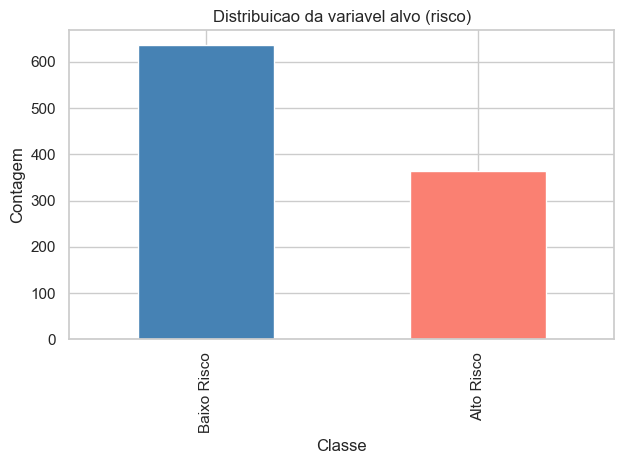

In [11]:
print(risco_credito['risco'].value_counts())
print('\nProporcao:')
print(risco_credito['risco'].value_counts(normalize=True).round(2))

risco_credito['risco'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Distribuicao da variavel alvo (risco)')
plt.xlabel('Classe')
plt.ylabel('Contagem')
plt.tight_layout()
plt.show()

Há uma concentração maior em baixo risco, mas não estão tao distantes

In [12]:
risco_credito['risco_num'] = risco_credito['risco'].map({'Alto Risco': 1, 'Baixo Risco': 0})

Criei uma coluna binaria de Risco para fazer a correlação mais pra frente

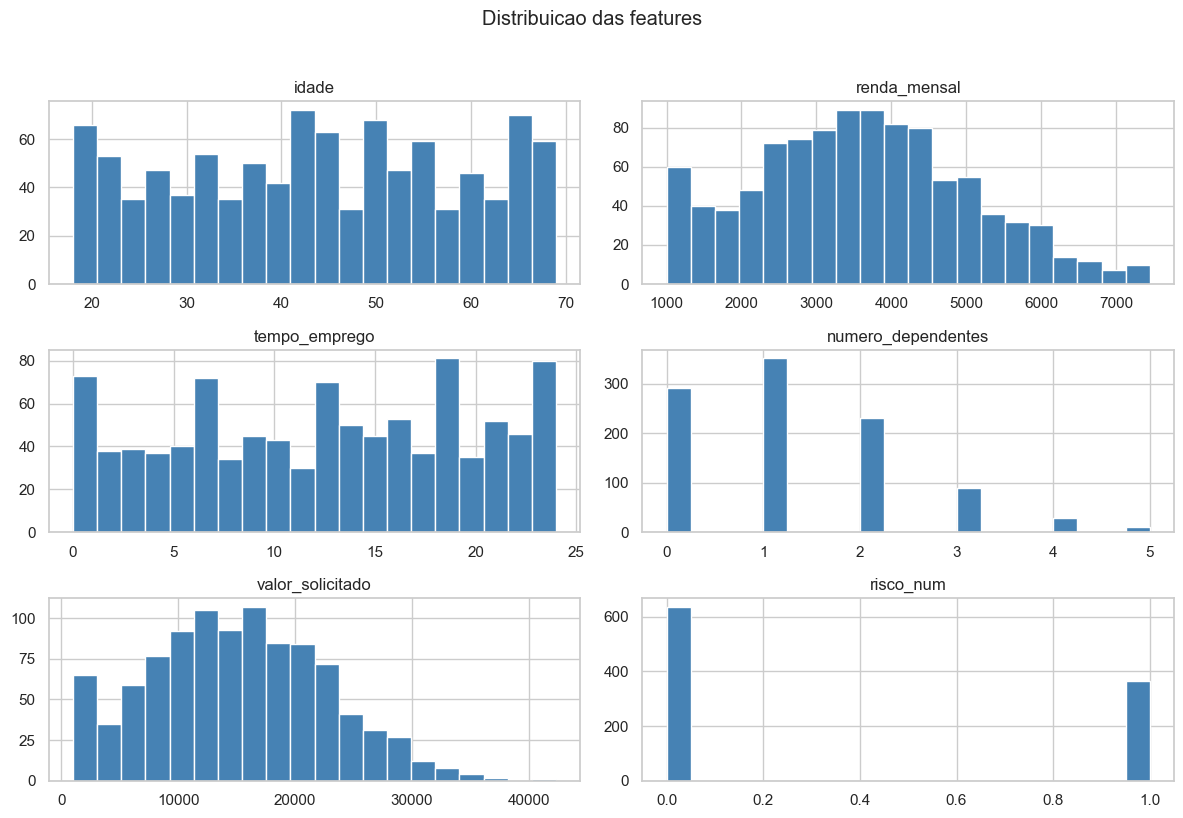

In [13]:
risco_credito.drop(columns='risco').hist(bins=20, figsize=(12, 8), color='steelblue', edgecolor='white')
plt.suptitle('Distribuicao das features', y=1.02)
plt.tight_layout()
plt.show()

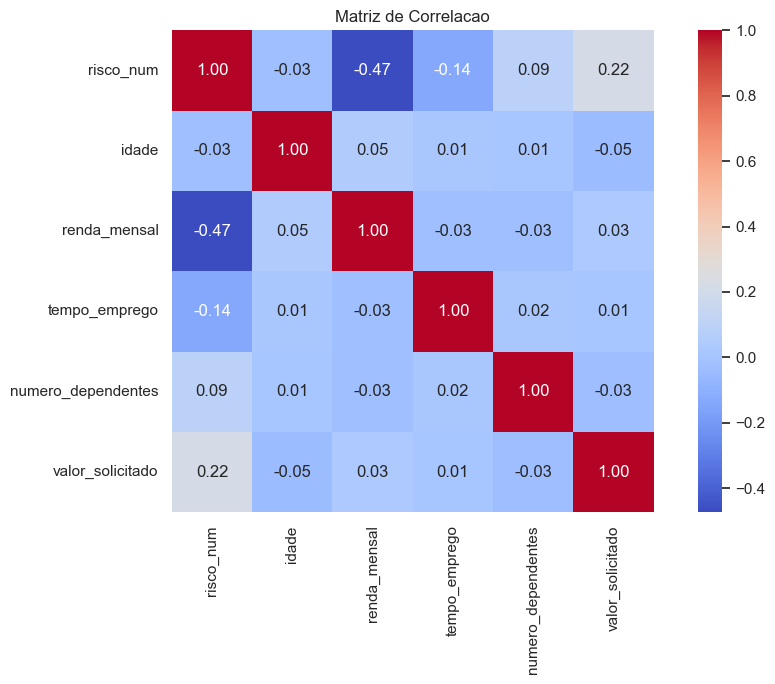

In [14]:
plt.figure(figsize=(10, 7))
sns.heatmap(risco_credito[['risco_num','idade', 'renda_mensal', 'tempo_emprego', 'numero_dependentes', 'valor_solicitado']].corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Matriz de Correlacao')
plt.tight_layout()
plt.show()

A unica que possui uma clara correlacao é a renda_mensal as demais nao apresentando correlação sifinificativa

**3.3 Identificação de padrões e outliers

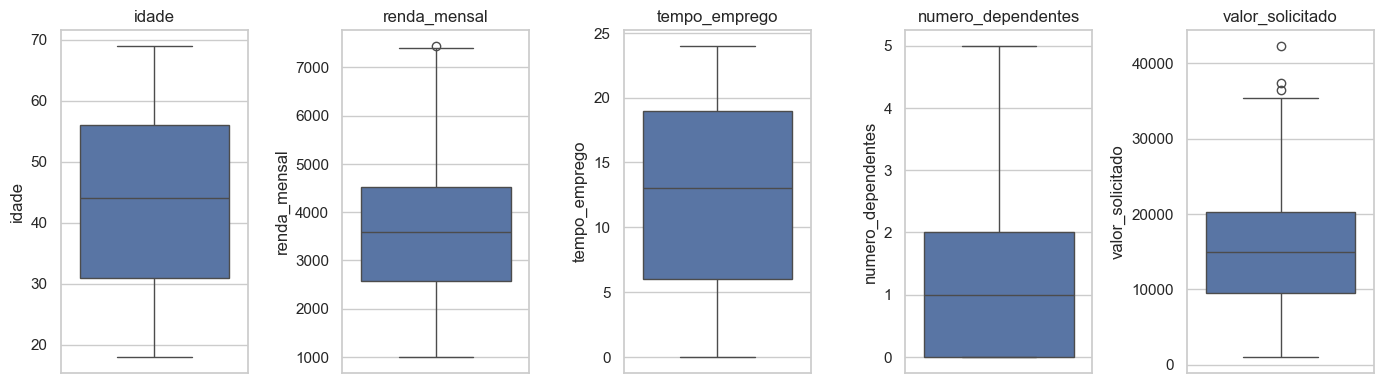

In [15]:
colunas_numericas = ['idade', 'renda_mensal', 'tempo_emprego', 'numero_dependentes', 'valor_solicitado']

fig, axes = plt.subplots(1, 5, figsize=(14, 4))

for ax, col in zip(axes, colunas_numericas):
    sns.boxplot(y=risco_credito[col], ax=ax)
    ax.set_title(col)

plt.tight_layout()

Apenas para o Valor solicitado existem outiliers, mas não acredito que devem ser removidos, uma vez que podem ser importantes para o modelo.

### 4 - Pré-processamento dos Dados

### 4.1 Tratamento efetivo de dados faltantes (imputação)

Não é necessario pois não existem valores faltantes

### 4.2 Normalização/Padronização 

Necessario normalizar e padronizar os valores pois o valor solcitado é distante dos demais

Como já era de se esperar a educação do individuo e o cargo que ocupa influencia diretamente na sua renda, assim como identificou também que os casados ou que vivem com alguem também possuem renda maior do que os demais.

In [16]:
# Separar features e variável alvo
features_to_drop = [col for col in ['risco_num', 'risco'] if col in risco_credito.columns]
X = risco_credito.drop(columns=features_to_drop)
y = risco_credito['risco_num']

# Identificar colunas numéricas e categóricas
colunas_numericas = X.select_dtypes(include=[np.number]).columns.tolist()
colunas_categoricas = X.select_dtypes(exclude=[np.number]).columns.tolist()

print('Variáveis numéricas:', colunas_numericas)
print('Variáveis categóricas:', colunas_categoricas)

Variáveis numéricas: ['idade', 'renda_mensal', 'tempo_emprego', 'numero_dependentes', 'valor_solicitado']
Variáveis categóricas: ['historico_credito', 'tipo_residencia', 'estado_civil', 'finalidade_credito']


Dividir em variaveis numericas e categoricas

In [17]:

# Dividir em treino e teste com estratificação
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f'Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras')

# Pipeline de pré-processamento
preprocessador = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), colunas_numericas),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), colunas_categoricas)
    ],
    remainder='drop'
)

# Aplicar transformação nas bases de treino e teste
X_train_prep = preprocessador.fit_transform(X_train)
X_test_prep = preprocessador.transform(X_test)

# Nome das colunas após one-hot encoding
nomes_colunas = preprocessador.get_feature_names_out()

X_train_prep_df = pd.DataFrame(X_train_prep, columns=nomes_colunas, index=X_train.index)
X_test_prep_df = pd.DataFrame(X_test_prep, columns=nomes_colunas, index=X_test.index)

print('\nShape após pré-processamento:')
print('Treino:', X_train_prep_df.shape)
print('Teste :', X_test_prep_df.shape)

X_train_prep_df.head()

Treino: 700 amostras | Teste: 300 amostras

Shape após pré-processamento:
Treino: (700, 22)
Teste : (300, 22)


,num__idade,num__renda_mensal,num__tempo_emprego,num__numero_dependentes,num__valor_solicitado,cat__historico_credito_Bom,cat__historico_credito_Excelente,cat__historico_credito_Regular,cat__historico_credito_Ruim,cat__tipo_residencia_Alugada,cat__tipo_residencia_Familiar,cat__tipo_residencia_Financiada,cat__tipo_residencia_Própria,cat__estado_civil_Casado,cat__estado_civil_Divorciado,cat__estado_civil_Solteiro,cat__estado_civil_Viúvo,cat__finalidade_credito_Educação,cat__finalidade_credito_Imóvel,cat__finalidade_credito_Negócio,cat__finalidade_credito_Pessoal,cat__finalidade_credito_Veículo
144,-1.714697,-1.107885,-1.493839,-0.223153,-1.081147,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
82,1.422874,1.220367,-0.225143,-1.152959,1.968824,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
321,1.422874,-0.547472,-1.775771,0.706653,0.191231,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
667,0.555035,-0.956290,1.607417,-0.223153,1.010032,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
347,-0.980372,-0.355663,-0.507075,-0.223153,-0.795138,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


Apos as transformações obtemos 22 features para ser utilizadas nos modelos, usando one hot encoder.

### 5. Seleção e Treinamento do Modelo

In [18]:
# Dicionario para guardar os resultados de cada modelo
resultados = {}

def avaliar_modelo(nome, modelo, X_tr, X_te, y_tr, y_te):
    modelo.fit(X_tr, y_tr)
    y_pred = modelo.predict(X_te)
    acc    = accuracy_score(y_te, y_pred)
    auc    = roc_auc_score(y_te, modelo.predict_proba(X_te)[:, 1])
    resultados[nome] = {'Acuracia': round(acc, 4), 'AUC-ROC': round(auc, 4)}
    print(f'\n--- {nome} ---')
    print(f'Acuracia: {acc:.4f} | AUC-ROC: {auc:.4f}')
    print(classification_report(y_te, y_pred, target_names=['Baixo Risco', 'Alto Risco']))
    # Matriz de confusao
    cm = confusion_matrix(y_te, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred 0', 'Pred 1'],
                yticklabels=['Real 0', 'Real 1'])
    plt.title(f'Matriz de Confusao - {nome}')
    plt.tight_layout()
    plt.show()
    return modelo

Vou treinar os 3 modelos sugeridos para a comparação desse dataset.

#### 5.1 Naivee bayes


--- Naive Bayes ---
Acuracia: 0.8200 | AUC-ROC: 0.8618
              precision    recall  f1-score   support

 Baixo Risco       0.83      0.91      0.86       191
  Alto Risco       0.80      0.67      0.73       109

    accuracy                           0.82       300
   macro avg       0.81      0.79      0.80       300
weighted avg       0.82      0.82      0.82       300



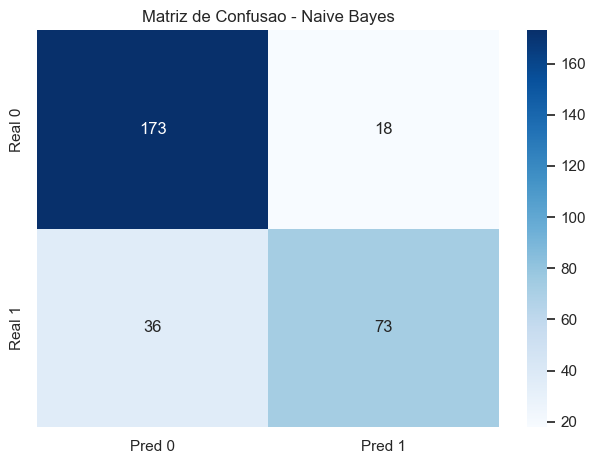

In [19]:
nb = avaliar_modelo('Naive Bayes', GaussianNB(),
                    X_train_prep_df, X_test_prep_df, y_train, y_test)

Performou razoaveu accuracia.

### 5.2 Redes Neurais


--- Rede Neural MLP ---
Acuracia: 0.9167 | AUC-ROC: 0.9762
              precision    recall  f1-score   support

 Baixo Risco       0.92      0.95      0.94       191
  Alto Risco       0.90      0.86      0.88       109

    accuracy                           0.92       300
   macro avg       0.91      0.91      0.91       300
weighted avg       0.92      0.92      0.92       300



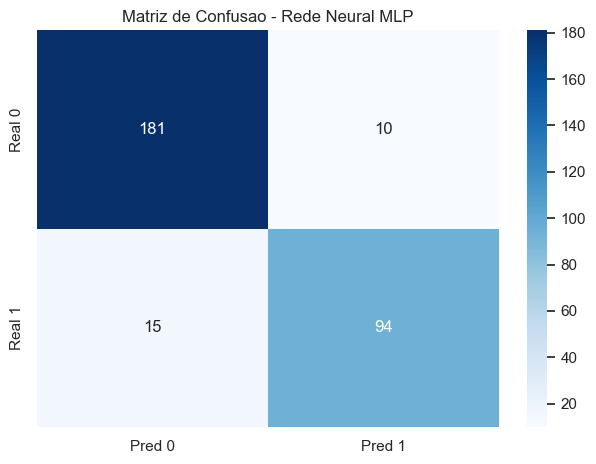

In [20]:
mlp = avaliar_modelo('Rede Neural MLP',
                     MLPClassifier(hidden_layer_sizes=(200,),
                                   activation='relu',
                                   max_iter=700,
                                   random_state=42),
                     X_train_prep_df, X_test_prep_df, y_train, y_test)

Performou muito bem com os valores ja selecionados, selecionei mais algumas alterações de hiperparametros mas a melhor foi:

max_iter |actiation| hidden_sizes| Accuracy | Macro avg | Weighted avg
|---|---|---|---|---|---|
700 | relu | 64,32| 0.903 |0.9| 0.9 
1000 | relu | 64,32| 0.903 |0.9| 0.9 
700 | logistic | 64,32| 0.88 |0.88| 0.88 
700 | relu | 100,| 0.916 |0.91| 0.92

O aumento do max iter nao trouxe melhoras no modelo, assim como a troca da função de ativação, porém o aumento do numero de neuronios da camada oculta aumentou a acuracia, porém o algoritmo demora mais para rodar o que pode ser um complicador para grandes datasets.


### 6. Avaliação do Modelo

In [21]:

# Avaliar o modelo selecionado sobre os dados de teste
if 'melhor_modelo' in globals() and 'X_test_prep_df' in globals() and 'y_test' in globals():
    y_pred = melhor_modelo.predict(X_test_prep_df)
    y_prob = melhor_modelo.predict_proba(X_test_prep_df)[:, 1]

    acuracia = accuracy_score(y_test, y_pred)
    precisao = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    recall = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    auc_roc = roc_auc_score(y_test, y_prob)

    print(f'Melhor modelo: {melhor_nome}')
    print(f'Acurácia: {acuracia:.4f}')
    print(f'Precisão: {precisao:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'F1-score: {f1:.4f}')
    print(f'AUC-ROC: {auc_roc:.4f}')
    print('\nRelatório de classificação:')
    print(classification_report(y_test, y_pred, target_names=['Baixo Risco', 'Alto Risco']))

    cm = confusion_matrix(y_test, y_pred)
    print('\nMatriz de confusão:')
    print(cm)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Baixo Risco', 'Alto Risco'],
                yticklabels=['Baixo Risco', 'Alto Risco'])
    plt.xlabel('Previsto')
    plt.ylabel('Real')
    plt.title('Matriz de confusão')
    plt.show()

    erros = X_test_prep_df.copy()
    erros['y_true'] = y_test
    erros['y_pred'] = y_pred
    erros['acertou'] = (y_test == y_pred)
    erros = erros[~erros['acertou']]

    print(f'\nTotal de erros: {len(erros)} de {len(X_test_prep_df)} amostras ({len(erros) / len(X_test_prep_df):.1%})')
    print('\nDistribuição dos erros por classe real:')
    print(erros['y_true'].value_counts().to_string())
else:
    print('Variáveis de treino/teste ou modelo não encontradas.')

Variáveis de treino/teste ou modelo não encontradas.


Os resultados  indicam que o modelo da rede neural apresentou bom desempenho na tarefa de classificação de risco de crédito, especialmente quando avaliado no conjunto de teste. A métrica de AUC-ROC mostrou uma alta capacidade do modelo em distinguir corretamente entre as classes de baixo e alto risco, enquanto a acurácia evidenciou uma performance geral consistente.

Ao analisar o relatório de classificação, observa-se que o modelo teve melhor desempenho na identificação de clientes de baixo risco do que de alto risco, o que pode ser explicado pela maior facilidade do algoritmo em reconhecer padrões associados à classe majoritária. Ainda assim, o desempenho para a classe de alto risco foi satisfatório, com valores adequados de precisão, recall e F1-score.

A matriz de confusão reforça essa interpretação, mostrando que a maior parte dos erros ocorreu na classificação incorreta de alguns casos de alto risco como baixo risco. Esse tipo de erro é importante em problemas financeiros, pois pode gerar decisões inadequadas relacionadas à concessão de crédito (acredito que seja melhor errar jogando avaliando como alto risco o que não tem tanta certeza)

Em relação ao custo computacional, a rede neural apresentou desempenho superior ao Naive Bayes, porém demandou mais tempo de treinamento, especialmente quando foram testados hiperparâmetros mais complexos. Dessa forma, conclui-se que o modelo escolhido oferece um bom equilíbrio entre desempenho preditivo e capacidade de generalização, sendo uma alternativa adequada para o problema solcitado no exercio e cumpre com o objetivo que foi designado.


In [23]:
joblib.dump(mlp, 'modelo_rede_neural_mlp.joblib')
joblib.dump(preprocessador, 'preprocessador_scaler.joblib')

print('Salvo com sucesso:')
print('- modelo: modelo_health_status_mlp.joblib')
print('- preprocessador: preprocessador_health_status_scaler.joblib')

Salvo com sucesso:
- modelo: modelo_health_status_mlp.joblib
- preprocessador: preprocessador_health_status_scaler.joblib
